# PHYS 771 HW2, James Dufresne, due July 5th 11:59pm


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from scipy.signal import lombscargle as ls
from tqdm import tqdm
import lightkurve as lk

# Problem 3

## loading TESS data (copied from example notebook)

Text(0.5, 0, 'Time (BTJD)')

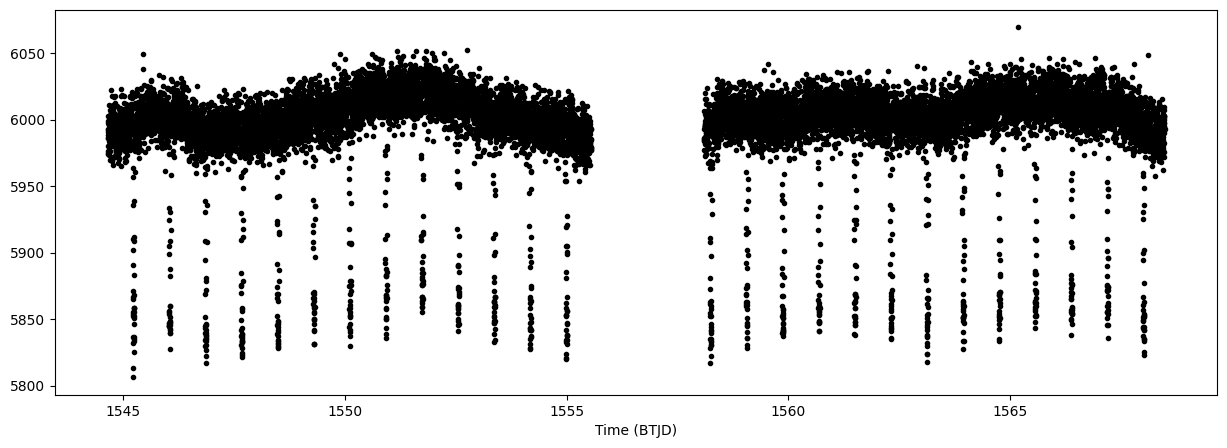

In [ ]:
# dataset information
tic = "TIC 36734222" # replace with the actual TIC ID
sector = 9 # March 2019 midpoint

# searching for the desired dataset
sr = lk.search_lightcurve(tic, mission="TESS", sector=sector)
# download the data and storing in variable lc
lc = sr.download()

# removing bad data (NaN values) 
lc = lc.remove_nans()
lc = lc[lc.quality == 0]
lc = lc[~lc.flux.mask]

# extracting time, flux, and exposure time
time = np.asarray(lc.time.value, dtype=float)
flux = np.asarray(lc.flux.value, dtype=float)

# remove any remaining NaNs
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

plt.figure(figsize=(15,5))
plt.plot(time, flux, "k.")
plt.xlabel("Time (BTJD)")
# plt.axvline(2338.7)
# plt.axvline(2342.1)
# print(2342.1-2338.7)

Period obtained from marking transits by eye: 0.813 days


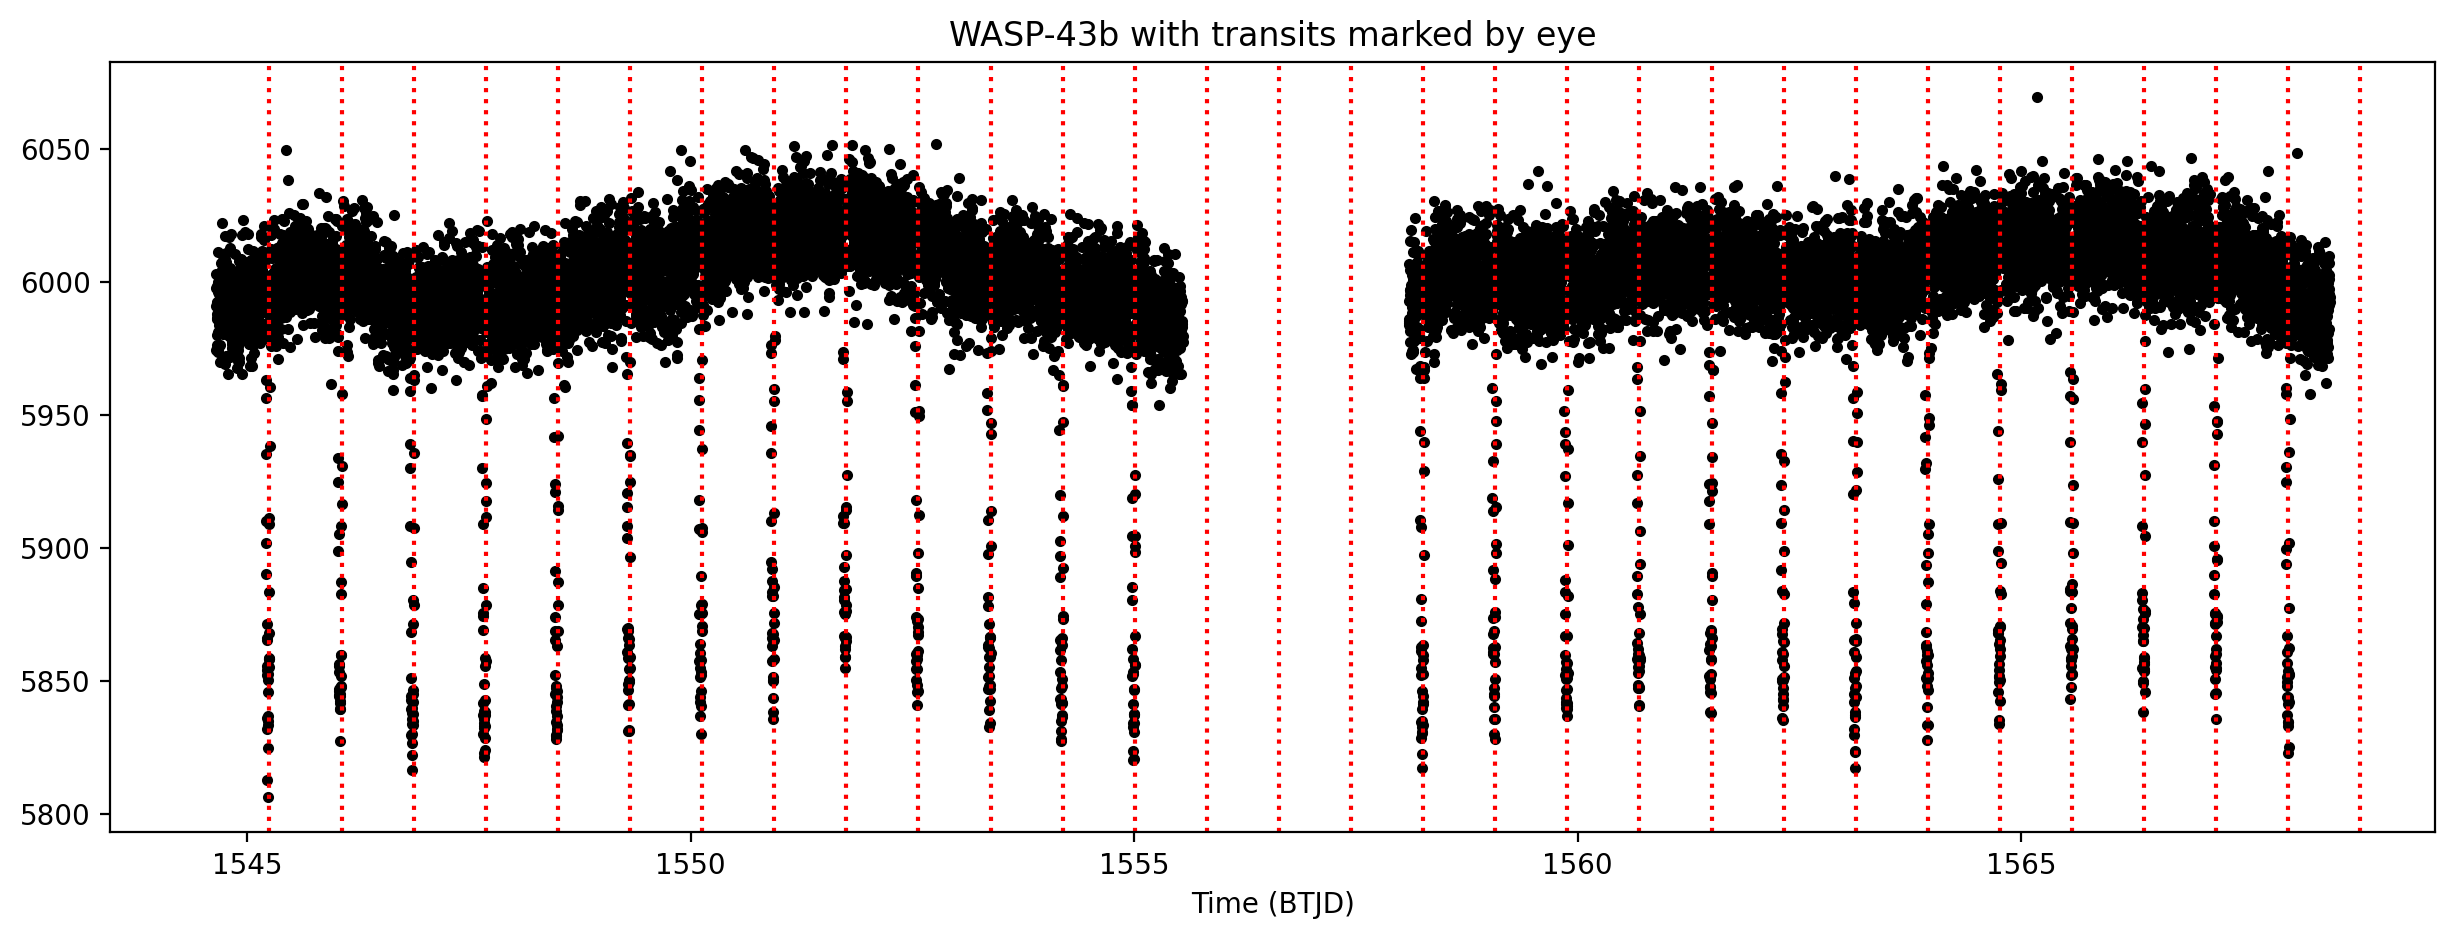

In [41]:
# sanity checks 
plt.figure(figsize=(15,5), dpi = 200)
plt.plot(time, flux, "k.")
plt.xlabel("Time (BTJD)")
plt.title("WASP-43b with transits marked by eye")

# identify transits by eye
period_by_eye = 0.813
for i in range(0,30):
    plt.axvline(1545.25+(i*period_by_eye), ls='dotted', c = 'red') # plot a red line at the first transit and every 0.813 days subsequent
print(f"Period obtained from marking transits by eye: {period_by_eye} days")

# literature values
